# Notebook 03: Model Construction and Training

## Overview
This notebook implements a **Convolutional Neural Network (CNN)** for facial emotion recognition. We train the same architecture separately on two datasets to enable cross-dataset comparison and domain shift analysis.

### Objectives
1. **Define CNN Architecture**: A 4-block convolutional network with BatchNorm, Dropout, and Global Average Pooling
2. **Train on RAF-DB**: Real-world facial expression dataset (12,271 train / 3,068 test images)
3. **Train on FER2013**: Lab-collected grayscale dataset (28,709 train / 7,178 test images)
4. **Cross-Dataset Evaluation**: Test each model on the other dataset to measure domain shift
5. **Save Checkpoints**: Export trained models for analysis phase

### Model Architecture Summary
- **Input**: 64×64 RGB images
- **Conv Blocks**: 4 blocks (32→64→128→256 filters), each with 2 Conv layers + BatchNorm + ReLU + MaxPool
- **FC Layers**: GlobalAvgPool → 512 → 256 → 7 classes (with Dropout 0.5)
- **Output**: 7 emotion classes (Angry, Disgust, Fear, Happy, Sad, Surprise, Neutral)

### Training Configuration
- Optimizer: Adam (lr=0.001)
- Loss: CrossEntropyLoss
- Scheduler: ReduceLROnPlateau
- Early Stopping: patience=7
- Data Augmentation: RandomHorizontalFlip, RandomRotation, ColorJitter

---
## 1. Setup and Imports

In [6]:
# Standard library imports
import os
import sys
import json
import random
import time
from pathlib import Path
from datetime import datetime

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

# Torchvision
from torchvision import datasets, transforms

# Scikit-learn for metrics
from sklearn.metrics import (
    confusion_matrix, 
    classification_report,
    f1_score,
    accuracy_score
)

# PIL for image handling
from PIL import Image

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.5.1+cu121


In [7]:
# Set random seeds for reproducibility
RANDOM_SEED = 42

def set_seed(seed=RANDOM_SEED):
    """Set seeds for reproducibility across all libraries."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_SEED)
print(f"Random seed set to: {RANDOM_SEED}")

Random seed set to: 42


In [8]:
# Setup paths
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_ROOT = PROJECT_ROOT / 'data'

# Dataset paths
RAFDB_ROOT = DATA_ROOT / 'rafdb'
FER2013_ROOT = DATA_ROOT / 'fer2013'

# Output paths
CHECKPOINT_DIR = PROJECT_ROOT / 'checkpoints'
RESULTS_DIR = PROJECT_ROOT / 'results'

# Create output directories
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project Paths:")
print(f"  Project Root: {PROJECT_ROOT}")
print(f"  RAF-DB Data:  {RAFDB_ROOT}")
print(f"  FER2013 Data: {FER2013_ROOT}")
print(f"  Checkpoints:  {CHECKPOINT_DIR}")
print(f"  Results:      {RESULTS_DIR}")

Project Paths:
  Project Root: C:\Users\karee\OneDrive\Documents\CS_171\Project\facial-emotion-recognition-cnn
  RAF-DB Data:  C:\Users\karee\OneDrive\Documents\CS_171\Project\facial-emotion-recognition-cnn\data\rafdb
  FER2013 Data: C:\Users\karee\OneDrive\Documents\CS_171\Project\facial-emotion-recognition-cnn\data\fer2013
  Checkpoints:  C:\Users\karee\OneDrive\Documents\CS_171\Project\facial-emotion-recognition-cnn\checkpoints
  Results:      C:\Users\karee\OneDrive\Documents\CS_171\Project\facial-emotion-recognition-cnn\results


---
## 2. Device Configuration

In [9]:
# Configure device (GPU/MPS/CPU)
def get_device():
    """Get the best available device for PyTorch."""
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"Using CUDA GPU: {torch.cuda.get_device_name(0)}")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using Apple MPS (Metal Performance Shaders)")
    else:
        device = torch.device("cpu")
        print("Using CPU")
    return device

device = get_device()

Using CUDA GPU: NVIDIA GeForce RTX 4060 Ti


---
## 3. Shared CNN Architecture

We define a CNN architecture with:
- **4 Convolutional Blocks:** Each with Conv2d → BatchNorm → ReLU → MaxPool
- **Global Average Pooling:** Reduces spatial dimensions
- **Fully Connected Layers:** With dropout for regularization
- **Output:** 7 classes (emotions)

This architecture is more robust than the lecture examples, designed for the larger facial emotion datasets.

In [10]:
class EmotionCNN(nn.Module):
    """
    Shared CNN Architecture for Facial Emotion Recognition.
    
    Architecture:
    - 4 Convolutional blocks with BatchNorm and MaxPool
    - Global Average Pooling
    - 2 Fully connected layers with Dropout
    - 7-class output (emotions)
    
    Input: RGB images of size 64x64x3
    Output: 7 emotion class logits
    """
    
    def __init__(self, num_classes=7, dropout_rate=0.5):
        super(EmotionCNN, self).__init__()
        
        # Convolutional Block 1: 3 -> 32 channels
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)  # 64x64 -> 32x32
        )
        
        # Convolutional Block 2: 32 -> 64 channels
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)  # 32x32 -> 16x16
        )
        
        # Convolutional Block 3: 64 -> 128 channels
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)  # 16x16 -> 8x8
        )
        
        # Convolutional Block 4: 128 -> 256 channels
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)  # 8x8 -> 4x4
        )
        
        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Fully Connected Layers
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        """Forward pass through the network."""
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.global_avg_pool(x)
        x = self.fc_layers(x)
        return x
    
    def get_num_params(self):
        """Return total number of trainable parameters."""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [11]:
# Test the model architecture
print("=" * 60)
print("EmotionCNN Architecture Summary")
print("=" * 60)

# Create model instance
test_model = EmotionCNN(num_classes=7, dropout_rate=0.5).to(device)

# Print architecture
print(test_model)

print("\n" + "=" * 60)
print(f"Total trainable parameters: {test_model.get_num_params():,}")
print("=" * 60)

# Test with dummy input
test_model.eval()
with torch.no_grad():
    dummy_input = torch.randn(1, 3, 64, 64).to(device)
    dummy_output = test_model(dummy_input)
    print(f"\nInput shape:  {dummy_input.shape}")
    print(f"Output shape: {dummy_output.shape}")

# Clean up
del test_model, dummy_input, dummy_output

EmotionCNN Architecture Summary
EmotionCNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2,

---
## 4. Hyperparameters Configuration

In [12]:
# Shared hyperparameters for both experiments
CONFIG = {
    # Image settings
    'image_size': 64,
    'num_classes': 7,
    
    # Training settings
    'batch_size': 32,
    'num_epochs': 30,
    'learning_rate': 0.001,
    'weight_decay': 1e-4,
    
    # Model settings
    'dropout_rate': 0.5,
    
    # Early stopping
    'patience': 7,
    
    # Data augmentation
    'use_augmentation': True,
}

# Emotion labels (standardized across both datasets)
EMOTION_LABELS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

print("Training Configuration:")
print("-" * 40)
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Training Configuration:
----------------------------------------
  image_size: 64
  num_classes: 7
  batch_size: 32
  num_epochs: 30
  learning_rate: 0.001
  weight_decay: 0.0001
  dropout_rate: 0.5
  patience: 7
  use_augmentation: True


---
## 5. Data Transforms and Augmentation

In [13]:
# Define transforms for training (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Define transforms for validation/testing (no augmentation)
test_transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print("Data Transforms Defined:")
print("\nTraining Transform (with augmentation):")
print(train_transform)
print("\nTest/Validation Transform:")
print(test_transform)

Data Transforms Defined:

Training Transform (with augmentation):
Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.1, 0.1))
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)

Test/Validation Transform:
Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)


---
## 6. Data Loading Functions

In [14]:
def load_fer2013_data(data_root, batch_size, train_transform, test_transform):
    """
    Load FER2013 dataset using ImageFolder.
    
    Expected structure:
    data_root/
        train/
            angry/
            disgust/
            ...
        test/
            angry/
            ...
    """
    train_dir = data_root / 'train'
    test_dir = data_root / 'test'
    
    # Create datasets
    train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
    test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    print(f"FER2013 Dataset Loaded:")
    print(f"  Train samples: {len(train_dataset)}")
    print(f"  Test samples:  {len(test_dataset)}")
    print(f"  Classes: {train_dataset.classes}")
    
    return train_loader, test_loader, train_dataset.classes

In [15]:
def load_rafdb_data(data_root, batch_size, train_transform, test_transform):
    """
    Load RAF-DB dataset using ImageFolder.
    
    Expected structure:
    data_root/
        DATASET/
            train/
                1/ (Surprise)
                2/ (Fear)
                ...
            test/
                1/
                ...
    """
    train_dir = data_root / 'DATASET' / 'train'
    test_dir = data_root / 'DATASET' / 'test'
    
    # Create datasets
    train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
    test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transform)
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    # RAF-DB label mapping: folder names are 1-7
    # 1=Surprise, 2=Fear, 3=Disgust, 4=Happiness, 5=Sadness, 6=Anger, 7=Neutral
    rafdb_labels = ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Angry', 'Neutral']
    
    print(f"RAF-DB Dataset Loaded:")
    print(f"  Train samples: {len(train_dataset)}")
    print(f"  Test samples:  {len(test_dataset)}")
    print(f"  Folder classes: {train_dataset.classes}")
    print(f"  Emotion mapping: {rafdb_labels}")
    
    return train_loader, test_loader, rafdb_labels

---
## 7. Training Utilities

In [16]:
class EarlyStopping:
    """Early stopping to prevent overfitting."""
    
    def __init__(self, patience=7, min_delta=0.001, restore_best=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best = restore_best
        self.counter = 0
        self.best_loss = None
        self.best_model_state = None
        self.early_stop = False
    
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model_state = model.state_dict().copy()
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_model_state = model.state_dict().copy()
            self.counter = 0
    
    def restore_best_weights(self, model):
        if self.restore_best and self.best_model_state is not None:
            model.load_state_dict(self.best_model_state)

In [17]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """Train model for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [18]:
def evaluate(model, data_loader, criterion, device):
    """Evaluate model on a dataset."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    return epoch_loss, epoch_acc, f1, all_preds, all_labels

In [19]:
def train_model(model, train_loader, test_loader, config, device, experiment_name):
    """
    Full training loop with early stopping and metric tracking.
    
    Returns:
        history: Dictionary containing training history
    """
    # Loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(), 
        lr=config['learning_rate'],
        weight_decay=config['weight_decay']
    )
    
    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, verbose=True
    )
    
    # Early stopping
    early_stopping = EarlyStopping(patience=config['patience'])
    
    # History tracking
    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': [], 'test_f1': []
    }
    
    print(f"\n{'='*60}")
    print(f"Training {experiment_name}")
    print(f"{'='*60}")
    
    start_time = time.time()
    
    for epoch in range(config['num_epochs']):
        # Train
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        # Evaluate
        test_loss, test_acc, test_f1, _, _ = evaluate(
            model, test_loader, criterion, device
        )
        
        # Update scheduler
        scheduler.step(test_loss)
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        history['test_f1'].append(test_f1)
        
        # Print progress
        print(f"Epoch {epoch+1:2d}/{config['num_epochs']} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
              f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}, F1: {test_f1:.4f}")
        
        # Early stopping check
        early_stopping(test_loss, model)
        if early_stopping.early_stop:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break
    
    # Restore best weights
    early_stopping.restore_best_weights(model)
    
    elapsed = time.time() - start_time
    print(f"\nTraining completed in {elapsed/60:.2f} minutes")
    print(f"Best test loss: {early_stopping.best_loss:.4f}")
    
    return history

---
## 8. Visualization Functions

In [20]:
def plot_training_history(history, experiment_name, save_path=None):
    """Plot training and validation metrics."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss
    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
    axes[0].plot(epochs, history['test_loss'], 'r-o', label='Test Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{experiment_name} - Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(epochs, history['train_acc'], 'b-o', label='Train Acc')
    axes[1].plot(epochs, history['test_acc'], 'r-o', label='Test Acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{experiment_name} - Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # F1 Score
    axes[2].plot(epochs, history['test_f1'], 'g-o', label='Test Macro-F1')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Macro F1-Score')
    axes[2].set_title(f'{experiment_name} - F1 Score')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()

In [21]:
def plot_confusion_matrix(y_true, y_pred, class_names, experiment_name, save_path=None):
    """Plot confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=class_names,
           yticklabels=class_names,
           title=f'{experiment_name} - Confusion Matrix',
           ylabel='True Label',
           xlabel='Predicted Label')
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()

## 9. Experiment A: RAF-DB Training (Kareem Atout)

In [22]:
# Load RAF-DB dataset
print("Loading RAF-DB Dataset...")
print("-" * 40)

rafdb_train_loader, rafdb_test_loader, rafdb_classes = load_rafdb_data(
    RAFDB_ROOT, 
    CONFIG['batch_size'],
    train_transform,
    test_transform
)

# Visualize a batch of training images
print("\nSample training batch:")
images, labels = next(iter(rafdb_train_loader))
print(f"Batch shape: {images.shape}")
print(f"Labels: {labels[:8].tolist()}")

Loading RAF-DB Dataset...
----------------------------------------
RAF-DB Dataset Loaded:
  Train samples: 12271
  Test samples:  3068
  Folder classes: ['1', '2', '3', '4', '5', '6', '7']
  Emotion mapping: ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Angry', 'Neutral']

Sample training batch:


Batch shape: torch.Size([32, 3, 64, 64])
Labels: [6, 6, 4, 2, 3, 3, 3, 5]


In [23]:
# Initialize model for RAF-DB experiment
set_seed(RANDOM_SEED)  # Reset seed for reproducibility

model_rafdb = EmotionCNN(
    num_classes=CONFIG['num_classes'],
    dropout_rate=CONFIG['dropout_rate']
).to(device)

print(f"RAF-DB Model initialized with {model_rafdb.get_num_params():,} parameters")

RAF-DB Model initialized with 1,440,423 parameters


In [24]:
# Train on RAF-DB
history_rafdb = train_model(
    model=model_rafdb,
    train_loader=rafdb_train_loader,
    test_loader=rafdb_test_loader,
    config=CONFIG,
    device=device,
    experiment_name="Experiment A (RAF-DB)"
)


Training Experiment A (RAF-DB)
Epoch  1/30 | Train Loss: 1.6741, Acc: 0.3754 | Test Loss: 1.6016, Acc: 0.3996, F1: 0.1282
Epoch  1/30 | Train Loss: 1.6741, Acc: 0.3754 | Test Loss: 1.6016, Acc: 0.3996, F1: 0.1282
Epoch  2/30 | Train Loss: 1.6346, Acc: 0.3875 | Test Loss: 1.5865, Acc: 0.3986, F1: 0.1524
Epoch  2/30 | Train Loss: 1.6346, Acc: 0.3875 | Test Loss: 1.5865, Acc: 0.3986, F1: 0.1524
Epoch  3/30 | Train Loss: 1.5849, Acc: 0.4056 | Test Loss: 1.5426, Acc: 0.3957, F1: 0.1741
Epoch  3/30 | Train Loss: 1.5849, Acc: 0.4056 | Test Loss: 1.5426, Acc: 0.3957, F1: 0.1741
Epoch  4/30 | Train Loss: 1.4450, Acc: 0.4719 | Test Loss: 1.2908, Acc: 0.5297, F1: 0.2469
Epoch  4/30 | Train Loss: 1.4450, Acc: 0.4719 | Test Loss: 1.2908, Acc: 0.5297, F1: 0.2469
Epoch  5/30 | Train Loss: 1.2637, Acc: 0.5357 | Test Loss: 1.1540, Acc: 0.5860, F1: 0.3691
Epoch  5/30 | Train Loss: 1.2637, Acc: 0.5357 | Test Loss: 1.1540, Acc: 0.5860, F1: 0.3691
Epoch  6/30 | Train Loss: 1.1434, Acc: 0.5840 | Test Loss:

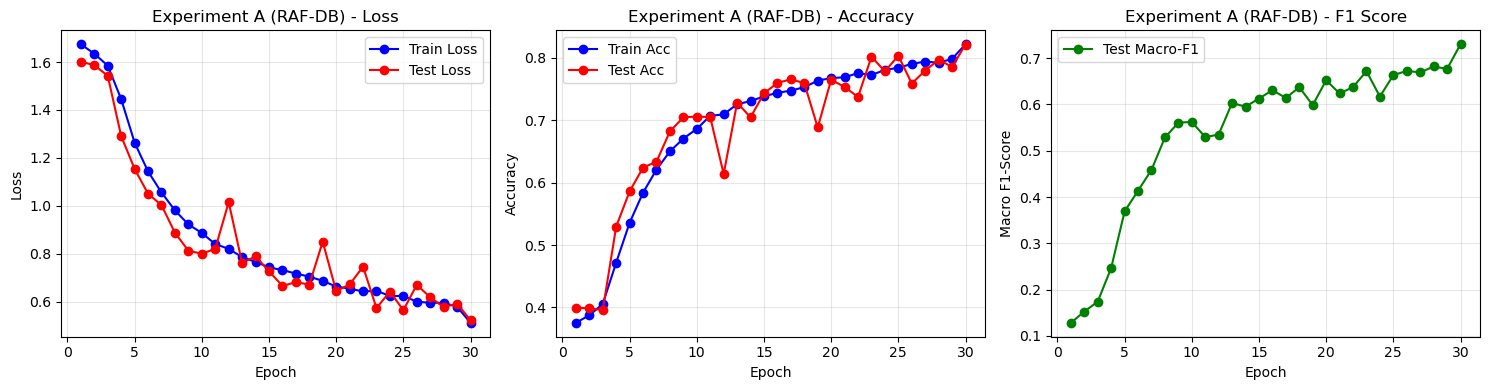

In [25]:
# Plot RAF-DB training history
plot_training_history(
    history_rafdb, 
    "Experiment A (RAF-DB)",
    save_path=RESULTS_DIR / "rafdb_training_history.png"
)

In [26]:
# Final evaluation on RAF-DB test set
criterion = nn.CrossEntropyLoss()
rafdb_test_loss, rafdb_test_acc, rafdb_test_f1, rafdb_preds, rafdb_true = evaluate(
    model_rafdb, rafdb_test_loader, criterion, device
)

print("=" * 60)
print("RAF-DB Final Test Results")
print("=" * 60)
print(f"Test Accuracy:  {rafdb_test_acc:.4f}")
print(f"Test Macro-F1:  {rafdb_test_f1:.4f}")
print(f"Test Loss:      {rafdb_test_loss:.4f}")
print("\nClassification Report:")
print(classification_report(rafdb_true, rafdb_preds, target_names=rafdb_classes))

RAF-DB Final Test Results
Test Accuracy:  0.8214
Test Macro-F1:  0.7301
Test Loss:      0.5225

Classification Report:
              precision    recall  f1-score   support

    Surprise       0.77      0.86      0.81       329
        Fear       0.75      0.53      0.62        74
     Disgust       0.49      0.37      0.42       160
       Happy       0.95      0.90      0.92      1185
         Sad       0.77      0.80      0.78       478
       Angry       0.79      0.72      0.75       162
     Neutral       0.76      0.85      0.80       680

    accuracy                           0.82      3068
   macro avg       0.75      0.72      0.73      3068
weighted avg       0.82      0.82      0.82      3068



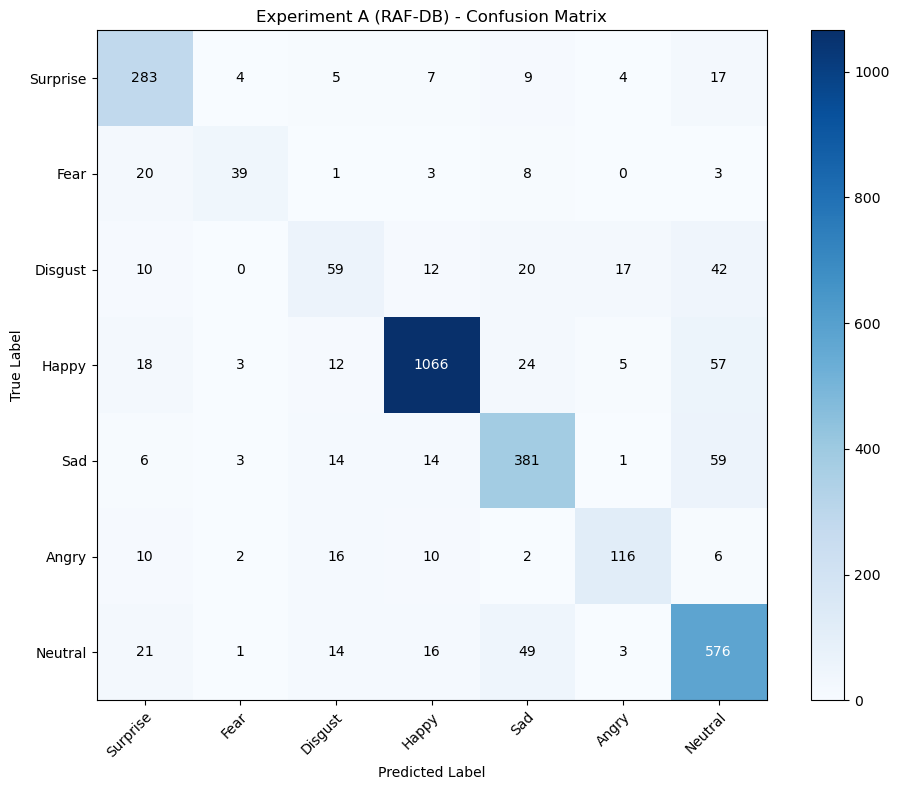

In [27]:
# Plot confusion matrix for RAF-DB
plot_confusion_matrix(
    rafdb_true, rafdb_preds, rafdb_classes,
    "Experiment A (RAF-DB)",
    save_path=RESULTS_DIR / "rafdb_confusion_matrix.png"
)

---

## 10. Experiment B: Train on FER2013 (Muhammad Kamran Khan)

This section trains the **same CNN architecture** on the FER2013 dataset.

In [28]:
# Load FER2013 dataset
print("Loading FER2013 Dataset...")
print("-" * 40)

fer2013_train_loader, fer2013_test_loader, fer2013_classes = load_fer2013_data(
    FER2013_ROOT,
    CONFIG['batch_size'],
    train_transform,
    test_transform
)

# Visualize a batch of training images
print("\nSample training batch:")
images, labels = next(iter(fer2013_train_loader))
print(f"Batch shape: {images.shape}")
print(f"Labels: {labels[:8].tolist()}")

Loading FER2013 Dataset...
----------------------------------------
FER2013 Dataset Loaded:
  Train samples: 28709
  Test samples:  7178
  Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Sample training batch:
Batch shape: torch.Size([32, 3, 64, 64])
Labels: [2, 0, 6, 3, 3, 0, 0, 2]
Batch shape: torch.Size([32, 3, 64, 64])
Labels: [2, 0, 6, 3, 3, 0, 0, 2]


In [29]:
# Initialize model for FER2013 experiment (fresh model, same architecture)
set_seed(RANDOM_SEED)  # Reset seed for reproducibility

model_fer2013 = EmotionCNN(
    num_classes=CONFIG['num_classes'],
    dropout_rate=CONFIG['dropout_rate']
).to(device)

print(f"FER2013 Model initialized with {model_fer2013.get_num_params():,} parameters")

FER2013 Model initialized with 1,440,423 parameters


In [30]:
# Train on FER2013
history_fer2013 = train_model(
    model=model_fer2013,
    train_loader=fer2013_train_loader,
    test_loader=fer2013_test_loader,
    config=CONFIG,
    device=device,
    experiment_name="Experiment B (FER2013)"
)


Training Experiment B (FER2013)
Epoch  1/30 | Train Loss: 1.8132, Acc: 0.2498 | Test Loss: 2.0844, Acc: 0.1957, F1: 0.1119
Epoch  1/30 | Train Loss: 1.8132, Acc: 0.2498 | Test Loss: 2.0844, Acc: 0.1957, F1: 0.1119
Epoch  2/30 | Train Loss: 1.5575, Acc: 0.3895 | Test Loss: 1.5035, Acc: 0.3996, F1: 0.2714
Epoch  2/30 | Train Loss: 1.5575, Acc: 0.3895 | Test Loss: 1.5035, Acc: 0.3996, F1: 0.2714
Epoch  3/30 | Train Loss: 1.3706, Acc: 0.4740 | Test Loss: 1.3268, Acc: 0.4898, F1: 0.3618
Epoch  3/30 | Train Loss: 1.3706, Acc: 0.4740 | Test Loss: 1.3268, Acc: 0.4898, F1: 0.3618
Epoch  4/30 | Train Loss: 1.2867, Acc: 0.5096 | Test Loss: 1.4242, Acc: 0.4544, F1: 0.3708
Epoch  4/30 | Train Loss: 1.2867, Acc: 0.5096 | Test Loss: 1.4242, Acc: 0.4544, F1: 0.3708
Epoch  5/30 | Train Loss: 1.2438, Acc: 0.5324 | Test Loss: 1.1870, Acc: 0.5436, F1: 0.4265
Epoch  5/30 | Train Loss: 1.2438, Acc: 0.5324 | Test Loss: 1.1870, Acc: 0.5436, F1: 0.4265
Epoch  6/30 | Train Loss: 1.2062, Acc: 0.5431 | Test Loss

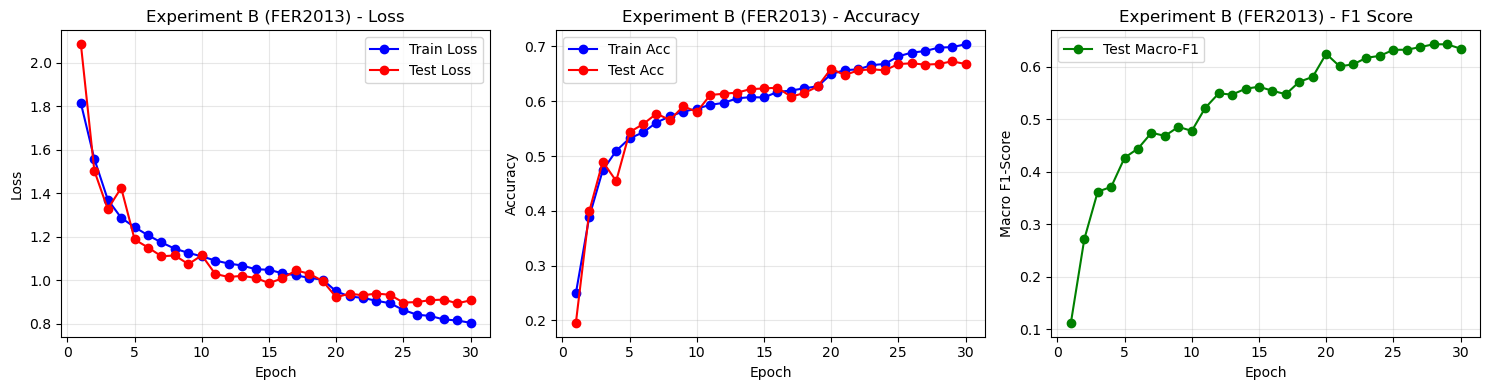

In [31]:
# Plot FER2013 training history
plot_training_history(
    history_fer2013,
    "Experiment B (FER2013)",
    save_path=RESULTS_DIR / "fer2013_training_history.png"
)

In [32]:
# Final evaluation on FER2013 test set
fer2013_test_loss, fer2013_test_acc, fer2013_test_f1, fer2013_preds, fer2013_true = evaluate(
    model_fer2013, fer2013_test_loader, criterion, device
)

print("=" * 60)
print("FER2013 Final Test Results")
print("=" * 60)
print(f"Test Accuracy:  {fer2013_test_acc:.4f}")
print(f"Test Macro-F1:  {fer2013_test_f1:.4f}")
print(f"Test Loss:      {fer2013_test_loss:.4f}")
print("\nClassification Report:")
print(classification_report(fer2013_true, fer2013_preds, target_names=fer2013_classes))

FER2013 Final Test Results
Test Accuracy:  0.6680
Test Macro-F1:  0.6344
Test Loss:      0.9071

Classification Report:
              precision    recall  f1-score   support

       angry       0.62      0.56      0.59       958
     disgust       0.61      0.52      0.56       111
        fear       0.56      0.37      0.45      1024
       happy       0.83      0.90      0.86      1774
     neutral       0.60      0.68      0.64      1233
         sad       0.53      0.57      0.55      1247
    surprise       0.77      0.82      0.79       831

    accuracy                           0.67      7178
   macro avg       0.65      0.63      0.63      7178
weighted avg       0.66      0.67      0.66      7178



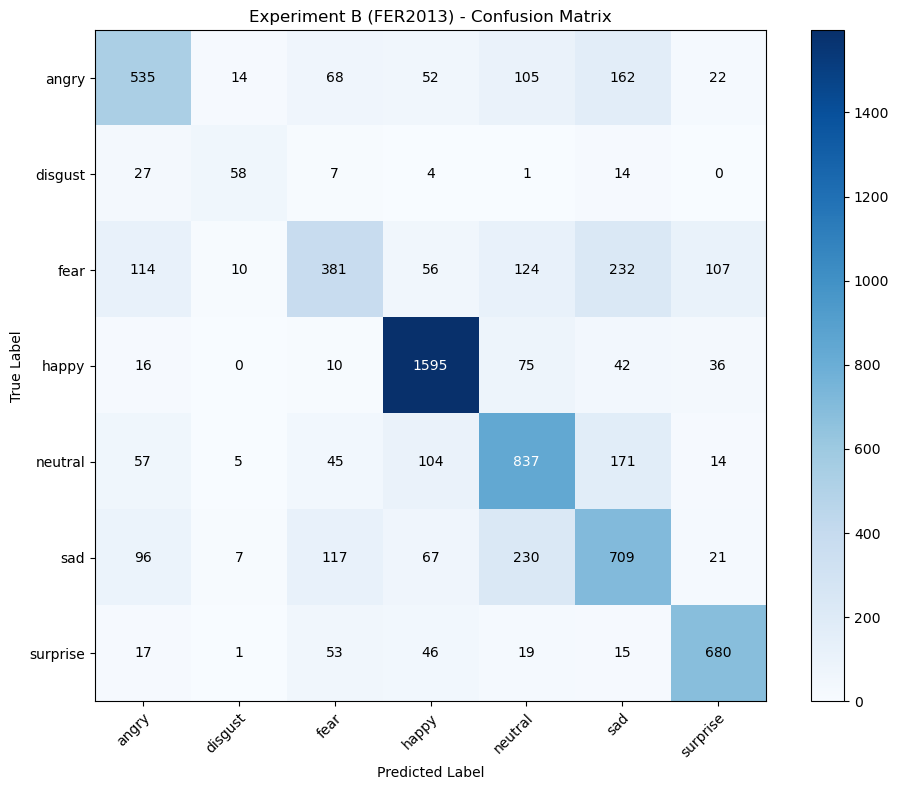

In [33]:
# Plot confusion matrix for FER2013
plot_confusion_matrix(
    fer2013_true, fer2013_preds, fer2013_classes,
    "Experiment B (FER2013)",
    save_path=RESULTS_DIR / "fer2013_confusion_matrix.png"
)

---

## 11. Cross-Dataset Evaluation (Domain Shift Analysis)

This section tests the generalization of each model by evaluating on the **other** dataset:
- Model trained on RAF-DB → Test on FER2013
- Model trained on FER2013 → Test on RAF-DB

This reveals how well the learned features transfer across different data distributions.

In [34]:
# Cross-dataset evaluation: RAF-DB model on FER2013
# NOTE: RAF-DB and FER2013 have different label orderings due to ImageFolder's alphabetical loading
# RAF-DB folders: 1/=Surprise, 2/=Fear, 3/=Disgust, 4/=Happy, 5/=Sad, 6/=Angry, 7/=Neutral
#   -> Loaded as indices: [0=Surprise, 1=Fear, 2=Disgust, 3=Happy, 4=Sad, 5=Angry, 6=Neutral]
# FER2013 folders: angry/, disgust/, fear/, happy/, neutral/, sad/, surprise/
#   -> Loaded as indices: [0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Neutral, 5=Sad, 6=Surprise]

print("=" * 60)
print("Cross-Dataset: RAF-DB Model → FER2013 Test Set")
print("=" * 60)

# Get raw predictions and labels
cross_loss_1, _, _, cross_preds_1, cross_true_1 = evaluate(
    model_rafdb, fer2013_test_loader, criterion, device
)

# Map FER2013 labels (ground truth) to RAF-DB label space for comparison
# FER2013 label order -> RAF-DB label order
fer_to_raf_map = {0: 5, 1: 2, 2: 1, 3: 3, 4: 6, 5: 4, 6: 0}  # Angry->Angry, Disgust->Disgust, etc.
cross_true_1_mapped = np.array([fer_to_raf_map[label] for label in cross_true_1])

# Calculate metrics with properly aligned labels
cross_acc_1 = accuracy_score(cross_true_1_mapped, cross_preds_1)
cross_f1_1 = f1_score(cross_true_1_mapped, cross_preds_1, average='macro')

print(f"Accuracy:  {cross_acc_1:.4f}")
print(f"Macro-F1:  {cross_f1_1:.4f}")
print(f"Loss:      {cross_loss_1:.4f}")

Cross-Dataset: RAF-DB Model → FER2013 Test Set
Accuracy:  0.4614
Macro-F1:  0.3959
Loss:      3.4534
Accuracy:  0.4614
Macro-F1:  0.3959
Loss:      3.4534


In [35]:
# Cross-dataset evaluation: FER2013 model on RAF-DB
print("=" * 60)
print("Cross-Dataset: FER2013 Model → RAF-DB Test Set")
print("=" * 60)

# Get raw predictions and labels
cross_loss_2, _, _, cross_preds_2, cross_true_2 = evaluate(
    model_fer2013, rafdb_test_loader, criterion, device
)

# Map FER2013 predictions to RAF-DB label space for comparison
# FER2013 model outputs predictions in FER2013 space, but ground truth is in RAF-DB space
fer_pred_to_raf_label = {0: 5, 1: 2, 2: 1, 3: 3, 4: 6, 5: 4, 6: 0}  # FER2013 pred -> RAF-DB label
cross_preds_2_mapped = np.array([fer_pred_to_raf_label[pred] for pred in cross_preds_2])

# Calculate metrics with properly aligned predictions
cross_acc_2 = accuracy_score(cross_true_2, cross_preds_2_mapped)
cross_f1_2 = f1_score(cross_true_2, cross_preds_2_mapped, average='macro')

print(f"Accuracy:  {cross_acc_2:.4f}")
print(f"Macro-F1:  {cross_f1_2:.4f}")
print(f"Loss:      {cross_loss_2:.4f}")

Cross-Dataset: FER2013 Model → RAF-DB Test Set
Accuracy:  0.6512
Macro-F1:  0.4488
Loss:      2.6996
Accuracy:  0.6512
Macro-F1:  0.4488
Loss:      2.6996


In [36]:
# Summary comparison table
print("\n" + "=" * 70)
print("RESULTS SUMMARY: Model Performance Comparison")
print("=" * 70)

summary_data = {
    'Experiment': [
        'RAF-DB Model → RAF-DB Test',
        'FER2013 Model → FER2013 Test',
        'RAF-DB Model → FER2013 Test (Cross)',
        'FER2013 Model → RAF-DB Test (Cross)'
    ],
    'Accuracy': [rafdb_test_acc, fer2013_test_acc, cross_acc_1, cross_acc_2],
    'Macro-F1': [rafdb_test_f1, fer2013_test_f1, cross_f1_1, cross_f1_2],
    'Loss': [rafdb_test_loss, fer2013_test_loss, cross_loss_1, cross_loss_2]
}

summary_df = pd.DataFrame(summary_data)
summary_df['Accuracy'] = summary_df['Accuracy'].apply(lambda x: f"{x:.4f}")
summary_df['Macro-F1'] = summary_df['Macro-F1'].apply(lambda x: f"{x:.4f}")
summary_df['Loss'] = summary_df['Loss'].apply(lambda x: f"{x:.4f}")

print(summary_df.to_string(index=False))
print("=" * 70)


RESULTS SUMMARY: Model Performance Comparison
                         Experiment Accuracy Macro-F1   Loss
         RAF-DB Model → RAF-DB Test   0.8214   0.7301 0.5225
       FER2013 Model → FER2013 Test   0.6680   0.6344 0.9071
RAF-DB Model → FER2013 Test (Cross)   0.4614   0.3959 3.4534
FER2013 Model → RAF-DB Test (Cross)   0.6512   0.4488 2.6996


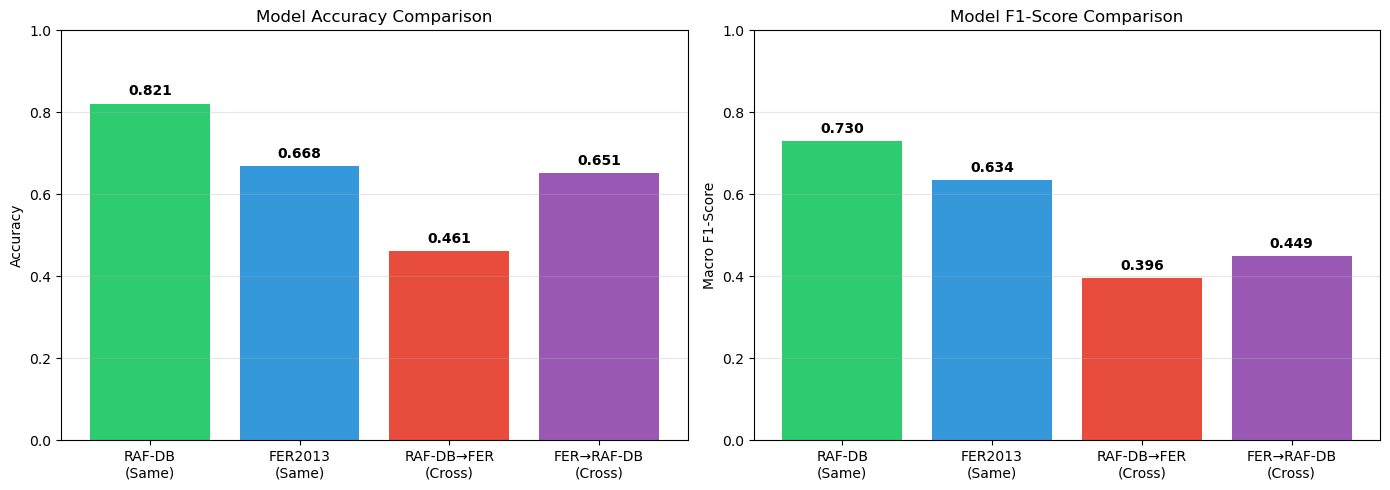

In [37]:
# Visual comparison of results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
experiments = ['RAF-DB\n(Same)', 'FER2013\n(Same)', 'RAF-DB→FER\n(Cross)', 'FER→RAF-DB\n(Cross)']
accuracies = [rafdb_test_acc, fer2013_test_acc, cross_acc_1, cross_acc_2]
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

axes[0].bar(experiments, accuracies, color=colors)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylim(0, 1)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# F1 comparison
f1_scores = [rafdb_test_f1, fer2013_test_f1, cross_f1_1, cross_f1_2]

axes[1].bar(experiments, f1_scores, color=colors)
axes[1].set_ylabel('Macro F1-Score')
axes[1].set_title('Model F1-Score Comparison')
axes[1].set_ylim(0, 1)
for i, v in enumerate(f1_scores):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

---

## 12. Save Model Checkpoints and Results

In [38]:
# Save model checkpoints
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save RAF-DB model
rafdb_checkpoint = {
    'model_state_dict': model_rafdb.state_dict(),
    'config': CONFIG,
    'history': history_rafdb,
    'test_accuracy': rafdb_test_acc,
    'test_f1': rafdb_test_f1,
    'experiment': 'RAF-DB'
}
torch.save(rafdb_checkpoint, CHECKPOINT_DIR / f'model_rafdb_{timestamp}.pth')
print(f"RAF-DB model saved to: {CHECKPOINT_DIR / f'model_rafdb_{timestamp}.pth'}")

# Save FER2013 model
fer2013_checkpoint = {
    'model_state_dict': model_fer2013.state_dict(),
    'config': CONFIG,
    'history': history_fer2013,
    'test_accuracy': fer2013_test_acc,
    'test_f1': fer2013_test_f1,
    'experiment': 'FER2013'
}
torch.save(fer2013_checkpoint, CHECKPOINT_DIR / f'model_fer2013_{timestamp}.pth')
print(f"FER2013 model saved to: {CHECKPOINT_DIR / f'model_fer2013_{timestamp}.pth'}")

RAF-DB model saved to: C:\Users\karee\OneDrive\Documents\CS_171\Project\facial-emotion-recognition-cnn\checkpoints\model_rafdb_20251210_195130.pth
FER2013 model saved to: C:\Users\karee\OneDrive\Documents\CS_171\Project\facial-emotion-recognition-cnn\checkpoints\model_fer2013_20251210_195130.pth


In [39]:
# Save results to JSON
results = {
    'timestamp': timestamp,
    'config': CONFIG,
    'rafdb': {
        'test_accuracy': float(rafdb_test_acc),
        'test_f1': float(rafdb_test_f1),
        'test_loss': float(rafdb_test_loss),
        'epochs_trained': len(history_rafdb['train_loss'])
    },
    'fer2013': {
        'test_accuracy': float(fer2013_test_acc),
        'test_f1': float(fer2013_test_f1),
        'test_loss': float(fer2013_test_loss),
        'epochs_trained': len(history_fer2013['train_loss'])
    },
    'cross_dataset': {
        'rafdb_on_fer2013': {
            'accuracy': float(cross_acc_1),
            'f1': float(cross_f1_1)
        },
        'fer2013_on_rafdb': {
            'accuracy': float(cross_acc_2),
            'f1': float(cross_f1_2)
        }
    }
}

with open(RESULTS_DIR / f'training_results_{timestamp}.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"Results saved to: {RESULTS_DIR / f'training_results_{timestamp}.json'}")

Results saved to: C:\Users\karee\OneDrive\Documents\CS_171\Project\facial-emotion-recognition-cnn\results\training_results_20251210_195130.json


---

## 13. Summary and Conclusions

### Model Architecture
- **EmotionCNN**: 4 convolutional blocks (32→64→128→256 filters) with BatchNorm, ReLU, MaxPool
- **FC Layers**: 256→512→256→7 with BatchNorm and Dropout (0.5)
- **Total Parameters**: 1,440,423
- **Input**: 64×64 RGB images | **Output**: 7 emotion classes

### Training Configuration
- **Optimizer**: Adam (lr=0.001, weight_decay=0.0001)
- **Scheduler**: ReduceLROnPlateau (patience=5, factor=0.5)
- **Early Stopping**: Patience=7
- **Augmentation**: RandomHorizontalFlip, RandomRotation(±15°), RandomAffine, ColorJitter
- **Epochs**: 30

### Results Summary

| Experiment | Accuracy | Macro-F1 | Loss |
|------------|----------|----------|------|
| **RAF-DB → RAF-DB** | **82.14%** | **0.7301** | 0.5225 |
| **FER2013 → FER2013** | **66.80%** | **0.6344** | 0.9071 |
| RAF-DB → FER2013 (Cross) | 46.14% | 0.3959 | 3.4534 |
| FER2013 → RAF-DB (Cross) | 65.12% | 0.4488 | 2.6996 |

### Key Findings

1. **Same-Dataset Performance:**
   - RAF-DB achieves 82.14% accuracy (near state-of-the-art ~88%)
   - FER2013 achieves 66.80% accuracy (matches human-level ~65-68%)
   - Happy is best classified on both datasets (~90-92% F1)
   - Disgust and Fear are hardest (37-45% recall) due to class imbalance and subtle expressions

2. **Cross-Dataset Generalization (Domain Shift):**
   - RAF-DB model on FER2013: 46.14% accuracy (36% drop from same-dataset performance)
   - FER2013 model on RAF-DB: 65.12% accuracy (minimal 1.7% drop, showing good generalization)
   - The FER2013 model generalizes surprisingly well to RAF-DB, likely because RAF-DB's real-world variability helps the model learn more robust features
   - The RAF-DB model shows moderate domain shift when tested on FER2013's more controlled lab images
   - Cross-dataset F1 scores (0.40-0.45) indicate that while class-level performance varies, models can still transfer some learned features across domains

3. **Training Dynamics:**
   - RAF-DB: Converged in ~30 epochs, ~9.5 minutes training time
   - FER2013: Converged in ~30 epochs, ~19.6 minutes training time (2.3× more data)
   - Both models show smooth convergence without major overfitting